In [12]:
import pandas as pd
import numpy as np

In [13]:
df_norm_counts = pd.read_csv("../results/GSE95640_DeSEQ2_normalized_counts.csv", index_col=0)
df_norm_counts

,GSM2520157,GSM2520158,GSM2520159,GSM2520160,GSM2520161,GSM2520162,GSM2520163,GSM2520164,GSM2520165,GSM2520166,...,GSM2520529,GSM2520530,GSM2520531,GSM2520532,GSM2520533,GSM2520534,GSM2520535,GSM2520536,GSM2520537,GSM2520538
GeneID,,,,,,,,,,,,,,,,,,,,,
100287102,21.005022,2.253288,9.606387,1.787645,2.985084,18.561131,4.279128,1.987068,7.709543,2.399610,...,1.001034,6.444927,6.151350,4.607232,5.725350,4.194643,2.588963,2.837753,7.136887,4.514742
653635,573.437111,482.203642,599.089232,362.891850,396.269921,491.324046,491.029974,419.271322,651.105935,295.951870,...,301.311342,479.789033,343.108653,310.220309,350.200585,442.954275,325.346371,303.639540,202.687600,558.323045
102466751,13.303181,11.266440,19.212774,8.938223,12.686608,13.101975,14.976949,14.903009,20.325158,9.598439,...,8.008275,20.766988,13.669667,6.910848,12.404925,24.328928,5.177926,8.513258,7.136887,15.049139
107985730,0.700167,0.000000,0.873308,0.000000,0.746271,1.091831,0.000000,0.993534,0.700868,0.799870,...,0.000000,0.716103,0.683483,1.535744,0.954225,0.838929,0.000000,0.945918,1.427377,0.752457
100302278,0.000000,0.000000,0.873308,0.000000,0.000000,0.000000,0.000000,0.000000,0.700868,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.945918,1.427377,0.752457
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4541,65218.493984,53285.755684,86956.142713,88890.626715,58519.589752,93704.230291,96074.988846,86339.092872,130099.236104,81206.793640,...,107583.164659,81885.665935,88575.344297,116805.625222,114593.837604,164748.788991,112876.205083,124964.224368,104541.125575,67572.137611
4556,5002.696163,3511.749418,7082.527216,7030.806131,4890.314115,7153.678115,7319.448977,5973.126044,9628.518126,6954.868955,...,8242.516914,6163.498821,7023.475145,8175.533749,8248.321125,11225.702951,7444.995078,9371.205374,6320.427417,6075.337287
4519,177973.454113,166229.565643,227802.370435,242588.732369,135318.342320,270049.165182,262076.283209,247025.323967,322034.612635,261377.493147,...,234232.029724,289490.380672,215474.968310,282656.006345,274298.663315,397946.597448,257454.264135,314770.152301,286750.141182,200003.053127


In [14]:
df_sample_annot = pd.read_csv("../results/GSE95640_sample_annotation.csv", index_col=0)
df_sample_annot

,sample_name,group,group_0_1
B00EVBV,GSM2520157,time: CID1 is for the baseline without LCD,0
B00EVBY,GSM2520158,time: CID1 is for the baseline without LCD,0
B00EVC0,GSM2520159,time: CID1 is for the baseline without LCD,0
B00EVC2,GSM2520160,time: CID1 is for the baseline without LCD,0
B00EVC4,GSM2520161,time: CID1 is for the baseline without LCD,0
...,...,...,...
B00EWA9,GSM2520534,time: CID2 is after 8 weeks of LCD,1
B00EWAE,GSM2520535,time: CID2 is after 8 weeks of LCD,1
B00EWAF,GSM2520536,time: CID2 is after 8 weeks of LCD,1
B00EWEV,GSM2520537,time: CID1 is for the baseline without LCD,0


In [15]:
df_gene_annot = pd.read_csv('../data/Human.GRCh38.p13.annot.tsv', sep='\t', index_col = None, header=0, low_memory=False)
df_gene_annot

,GeneID,Symbol,Description,Synonyms,GeneType,EnsemblGeneID,Status,ChrAcc,ChrStart,ChrStop,Orientation,Length,GOFunctionID,GOProcessID,GOComponentID,GOFunction,GOProcess,GOComponent
0,100287102,DDX11L1,DEAD/H-box helicase 11 like 1 (pseudogene),NaN,pseudo,ENSG00000290825,active,NC_000001.11,11874,14409,positive,1652,NaN,NaN,NaN,NaN,NaN,NaN
1,653635,WASH7P,"WASP family homolog 7, pseudogene",FAM39F|WASH5P,pseudo,NaN,active,NC_000001.11,14362,29370,negative,1769,NaN,NaN,NaN,NaN,NaN,NaN
2,102466751,MIR6859-1,microRNA 6859-1,hsa-mir-6859-1,ncRNA,ENSG00000278267,active,NC_000001.11,17369,17436,negative,68,NaN,NaN,NaN,NaN,NaN,NaN
3,107985730,MIR1302-2HG,MIR1302-2 host gene,NaN,ncRNA,NaN,active,NC_000001.11,29926,31295,positive,538,NaN,NaN,NaN,NaN,NaN,NaN
4,100302278,MIR1302-2,microRNA 1302-2,MIRN1302-2|hsa-mir-1302-2,ncRNA,ENSG00000284332,active,NC_000001.11,30366,30503,positive,138,NaN,GO:0035195,NaN,NaN,miRNA-mediated gene silencing,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39371,4541,ND6,NADH dehydrogenase subunit 6,MTND6,protein-coding,NaN,active,NC_012920.1,14149,14673,negative,525,GO:0008137,GO:0006120///GO:0009060///GO:0032981///GO:0035...,GO:0005739///GO:0005743///GO:0005747,NADH dehydrogenase (ubiquinone) activity,"mitochondrial electron transport, NADH to ubiq...",mitochondrion///mitochondrial inner membrane//...
39372,4556,TRNE,tRNA-Glu,MTTE,tRNA,NaN,active,NC_012920.1,14674,14742,negative,69,NaN,NaN,NaN,NaN,NaN,NaN
39373,4519,CYTB,cytochrome b,MTCYB,protein-coding,NaN,active,NC_012920.1,14747,15887,positive,1141,GO:0008121///GO:0046872,GO:0006122///GO:0045333///GO:1902600,GO:0005739///GO:0005743///GO:0005750///GO:0016020,ubiquinol-cytochrome-c reductase activity///me...,"mitochondrial electron transport, ubiquinol to...",mitochondrion///mitochondrial inner membrane//...
39374,4576,TRNT,tRNA-Thr,MTTT,tRNA,NaN,active,NC_012920.1,15888,15953,positive,66,NaN,NaN,NaN,NaN,NaN,NaN


In [21]:
# Import required libraries for differential expression analysis
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.multitest import multipletests
import warnings
warnings.filterwarnings('ignore')

print("Starting differential expression analysis using existing dataframes:")
print(f"- df_norm_counts shape: {df_norm_counts.shape}")
print(f"- df_sample_annot shape: {df_sample_annot.shape}")
print(f"- df_gene_annot shape: {df_gene_annot.shape}")

Starting differential expression analysis using existing dataframes:
- df_norm_counts shape: (39376, 382)
- df_sample_annot shape: (382, 3)
- df_gene_annot shape: (39376, 18)


In [22]:
# Prepare sample groups for differential expression analysis
print("Preparing sample groups...")

# Create mapping from sample_name to group
sample_to_group = df_sample_annot.set_index('sample_name')['group_0_1'].to_dict()

# Get samples that exist in both normalized counts and sample annotation
available_samples = df_norm_counts.columns.intersection(df_sample_annot['sample_name'])
print(f"Samples available in both datasets: {len(available_samples)}")

# Filter normalized counts to common samples
df_counts_analysis = df_norm_counts[available_samples]

# Create group assignments
baseline_samples = [s for s in available_samples if sample_to_group[s] == 0]
treated_samples = [s for s in available_samples if sample_to_group[s] == 1]

print(f"Baseline samples (group 0): {len(baseline_samples)}")
print(f"Treated samples (group 1): {len(treated_samples)}")

# Get expression data for each group
baseline_data = df_counts_analysis[baseline_samples]
treated_data = df_counts_analysis[treated_samples]

print(f"Baseline data shape: {baseline_data.shape}")
print(f"Treated data shape: {treated_data.shape}")

Preparing sample groups...
Samples available in both datasets: 382
Baseline samples (group 0): 191
Treated samples (group 1): 191
Baseline data shape: (39376, 191)
Treated data shape: (39376, 191)


In [23]:
# Prepare data for DESeq2 analysis
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

print("Setting up DESeq2 analysis...")

# Convert normalized counts back to pseudo raw counts for DESeq2
# DESeq2 expects raw counts, so we'll scale up the normalized counts
scale_factor = 1000
pseudo_counts = (df_counts_analysis * scale_factor).round().astype(int)

# Transpose to get samples as rows (required by pyDESeq2)
counts_matrix = pseudo_counts.T

print(f"Pseudo counts matrix shape (samples x genes): {counts_matrix.shape}")

# Create metadata DataFrame
metadata = pd.DataFrame({
    'sample_id': available_samples,
    'condition': [sample_to_group[s] for s in available_samples]
})
metadata['condition'] = metadata['condition'].map({0: 'baseline', 1: 'treated'})
metadata.set_index('sample_id', inplace=True)

print(f"Metadata shape: {metadata.shape}")
print("Condition distribution:")
print(metadata['condition'].value_counts())

# Ensure metadata index matches counts matrix index
metadata = metadata.loc[counts_matrix.index]

print("Data prepared for DESeq2 analysis")

Setting up DESeq2 analysis...
Pseudo counts matrix shape (samples x genes): (382, 39376)
Metadata shape: (382, 1)
Condition distribution:
condition
baseline    191
treated     191
Name: count, dtype: int64
Data prepared for DESeq2 analysis


In [24]:
# Run DESeq2 analysis
print("Running DESeq2 differential expression analysis...")

try:
    # Create DESeqDataSet
    dds = DeseqDataSet(
        counts=counts_matrix,
        metadata=metadata,
        design_factors="condition",
        ref_level=["condition", "baseline"]
    )
    
    print("DESeqDataSet created successfully")
    
    # Run DESeq2 analysis
    print("Running DESeq2...")
    dds.deseq2()
    print("DESeq2 analysis completed")
    
    # Get statistical results
    print("Computing statistical results...")
    stat_res = DeseqStats(dds, contrast=["condition", "treated", "baseline"])
    stat_res.summary()
    
    # Extract results
    deseq2_results = stat_res.results_df.copy()
    
    print(f"DESeq2 results shape: {deseq2_results.shape}")
    print("\nDESeq2 results columns:")
    print(deseq2_results.columns.tolist())
    
    print("\nFirst few DESeq2 results:")
    print(deseq2_results.head())
    
    # Add gene_id column for easier merging
    deseq2_results.reset_index(inplace=True)
    deseq2_results.rename(columns={'index': 'gene_id'}, inplace=True)
    
    print("DESeq2 analysis completed successfully!")
    
except Exception as e:
    print(f"Error running DESeq2: {e}")
    print("This might be due to data format issues with pyDESeq2")
    raise

Running DESeq2 differential expression analysis...
DESeqDataSet created successfully
Running DESeq2...
Using None as control genes, passed at DeseqDataSet initialization
DESeqDataSet created successfully
Running DESeq2...
Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.28 seconds.

... done in 0.28 seconds.

Fitting dispersions...
Fitting dispersions...
... done in 3.25 seconds.

Fitting dispersion trend curve...
... done in 3.25 seconds.

Fitting dispersion trend curve...
... done in 0.73 seconds.

Fitting MAP dispersions...
... done in 0.73 seconds.

Fitting MAP dispersions...
... done in 3.23 seconds.

Fitting LFCs...
... done in 3.23 seconds.

Fitting LFCs...
... done in 3.47 seconds.

Calculating cook's distance...
... done in 3.47 seconds.

Calculating cook's distance...
... done in 0.59 seconds.

Replacing 7507 outlier genes.

... done in 0.59 seconds.

Replacing 7507 outlier genes.

Fitting dispersions...
... done in 0.20 seconds.

Fitting MAP dispersions...
Fitting dispersions...
... done in 0.20 seconds.

Fitting MAP dispersions...
... done in 0.15 seconds.

Fitting LFCs...
... done in 0.15 seconds.

Fitting LFCs...
... done in 1.58 seconds.

... done in 1.58 seconds.



DESeq2 analysis completed
Computing statistical results...


Running Wald tests...


Log2 fold change & Wald test p-value: condition treated vs baseline
               baseMean  log2FoldChange     lfcSE      stat        pvalue  \
GeneID                                                                      
100287102  6.554542e+03       -0.194638  0.100690 -1.933039  5.323143e-02   
653635     3.421119e+05        0.061290  0.050958  1.202752  2.290722e-01   
102466751  1.009878e+04        0.187805  0.067334  2.789146  5.284718e-03   
107985730  5.531296e+02       -0.376069  0.443386 -0.848175  3.963406e-01   
100302278  1.700084e+02       -0.488108  0.990818 -0.492632  6.222730e-01   
...                 ...             ...       ...       ...           ...   
4541       9.581418e+07       -0.156821  0.049399 -3.174578  1.500548e-03   
4556       7.597892e+06       -0.246617  0.047056 -5.240899  1.597958e-07   
4519       2.648035e+08       -0.257961  0.052639 -4.900589  9.554952e-07   
4576       6.969891e+05       -0.329584  0.059863 -5.505645  3.678199e-08   
4571    

... done in 0.87 seconds.



In [29]:
# Extract and annotate DESeq2 results
print("Processing DESeq2 results...")

# The DESeq2 results already contain gene IDs and all necessary columns
print("DESeq2 results summary:")
print(f"Total genes analyzed: {len(deseq2_results)}")
print(f"Genes with p-value < 0.05: {(deseq2_results['pvalue'] < 0.05).sum()}")
print(f"Genes with FDR < 0.05: {(deseq2_results['padj'] < 0.05).sum()}")

# Add gene annotations
print("\nAdding gene annotations...")

# The DESeq2 results already have 'GeneID' column, so we merge directly
deseq2_with_annot = deseq2_results.merge(
    df_gene_annot,
    on='GeneID',  # Both dataframes have 'GeneID' column
    how='left'
)

print(f"Results with annotations shape: {deseq2_with_annot.shape}")

# Display basic statistics
print(f"\nDESeq2 Results Statistics:")
print(f"Mean log2FoldChange: {deseq2_results['log2FoldChange'].mean():.3f}")
print(f"Std log2FoldChange: {deseq2_results['log2FoldChange'].std():.3f}")
print(f"Mean baseMean: {deseq2_results['baseMean'].mean():.1f}")

print(f"\nFirst few annotated results:")
display_cols = ['GeneID', 'log2FoldChange', 'pvalue', 'padj', 'baseMean']

# Add gene symbol if available
symbol_cols = ['Gene_Symbol', 'gene_symbol', 'Symbol', 'symbol', 'Gene_Name', 'gene_name']
for col in symbol_cols:
    if col in deseq2_with_annot.columns:
        display_cols.insert(1, col)
        break

print(deseq2_with_annot[display_cols].head())

Processing DESeq2 results...
DESeq2 results summary:
Total genes analyzed: 39376
Genes with p-value < 0.05: 11062
Genes with FDR < 0.05: 8755

Adding gene annotations...
Results with annotations shape: (39376, 24)

DESeq2 Results Statistics:
Mean log2FoldChange: 0.068
Std log2FoldChange: 1.369
Mean baseMean: 575927.9

First few annotated results:
      GeneID       Symbol  log2FoldChange    pvalue      padj       baseMean
0  100287102      DDX11L1       -0.194638  0.053231  0.116475    6554.542486
1     653635       WASH7P        0.061290  0.229072  0.363471  342111.924866
2  102466751    MIR6859-1        0.187805  0.005285  0.017097   10098.780045
3  107985730  MIR1302-2HG       -0.376069  0.396341       NaN     553.129558
4  100302278    MIR1302-2       -0.488108  0.622273       NaN     170.008382


In [30]:
# Filter for significant differentially expressed genes
print("Filtering significant genes...")

# Apply significance filters: p-value < 0.05 and |log2FC| > 1
significant_genes = deseq2_with_annot[
    (deseq2_with_annot['pvalue'] < 0.05) & 
    (abs(deseq2_with_annot['log2FoldChange']) > 1)
]

print(f"Significant genes (p < 0.05, |log2FC| > 1): {len(significant_genes)}")

# Also filter by FDR
significant_genes_fdr = deseq2_with_annot[
    (deseq2_with_annot['padj'] < 0.05) & 
    (abs(deseq2_with_annot['log2FoldChange']) > 1)
]

print(f"Significant genes (FDR < 0.05, |log2FC| > 1): {len(significant_genes_fdr)}")

# Separate upregulated and downregulated genes
upregulated = significant_genes[significant_genes['log2FoldChange'] > 1]
downregulated = significant_genes[significant_genes['log2FoldChange'] < -1]

print(f"\nGene regulation summary:")
print(f"Upregulated genes (log2FC > 1): {len(upregulated)}")
print(f"Downregulated genes (log2FC < -1): {len(downregulated)}")

# Sort by significance (p-value)
significant_genes_sorted = significant_genes.sort_values('pvalue')

print(f"\nTop 10 most significant differentially expressed genes:")
print(significant_genes_sorted[display_cols].head(10))

# Save results
print(f"\nSaving results...")
deseq2_with_annot.to_csv("../results/DESeq2_all_results.csv", index=False)
significant_genes.to_csv("../results/DESeq2_significant_genes.csv", index=False)

print("Results saved to:")
print("- ../results/DESeq2_all_results.csv")
print("- ../results/DESeq2_significant_genes.csv")

Filtering significant genes...
Significant genes (p < 0.05, |log2FC| > 1): 576
Significant genes (FDR < 0.05, |log2FC| > 1): 80

Gene regulation summary:
Upregulated genes (log2FC > 1): 354
Downregulated genes (log2FC < -1): 222

Top 10 most significant differentially expressed genes:
          GeneID        Symbol  log2FoldChange        pvalue          padj  \
22094       9415         FADS2       -1.763532  5.203351e-73  1.211861e-68   
31176        230         ALDOC       -1.235490  3.517544e-66  4.096180e-62   
13749     221262      CCDC162P       -1.252972  4.293628e-59  3.333286e-55   
20692       6319           SCD       -1.875106  1.049648e-56  6.111574e-53   
22092       3992         FADS1       -1.551051  9.697503e-53  4.517097e-49   
9736       79071        ELOVL6       -1.525736  2.201496e-50  8.545472e-47   
38904     286411     LINC00632       -1.221395  7.055636e-50  2.347511e-46   
22852  105369488  LOC105369488       -1.838154  2.030957e-48  3.941749e-45   
10878     28

In [34]:
deseq2_with_annot


,GeneID,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Symbol,Description,Synonyms,...,ChrStart,ChrStop,Orientation,Length,GOFunctionID,GOProcessID,GOComponentID,GOFunction,GOProcess,GOComponent
0,100287102,6.554542e+03,-0.194638,0.100690,-1.933039,5.323143e-02,1.164750e-01,DDX11L1,DEAD/H-box helicase 11 like 1 (pseudogene),NaN,...,11874,14409,positive,1652,NaN,NaN,NaN,NaN,NaN,NaN
1,653635,3.421119e+05,0.061290,0.050958,1.202752,2.290722e-01,3.634709e-01,WASH7P,"WASP family homolog 7, pseudogene",FAM39F|WASH5P,...,14362,29370,negative,1769,NaN,NaN,NaN,NaN,NaN,NaN
2,102466751,1.009878e+04,0.187805,0.067334,2.789146,5.284718e-03,1.709697e-02,MIR6859-1,microRNA 6859-1,hsa-mir-6859-1,...,17369,17436,negative,68,NaN,NaN,NaN,NaN,NaN,NaN
3,107985730,5.531296e+02,-0.376069,0.443386,-0.848175,3.963406e-01,NaN,MIR1302-2HG,MIR1302-2 host gene,NaN,...,29926,31295,positive,538,NaN,NaN,NaN,NaN,NaN,NaN
4,100302278,1.700084e+02,-0.488108,0.990818,-0.492632,6.222730e-01,NaN,MIR1302-2,microRNA 1302-2,MIRN1302-2|hsa-mir-1302-2,...,30366,30503,positive,138,NaN,GO:0035195,NaN,NaN,miRNA-mediated gene silencing,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39371,4541,9.581418e+07,-0.156821,0.049399,-3.174578,1.500548e-03,5.862733e-03,ND6,NADH dehydrogenase subunit 6,MTND6,...,14149,14673,negative,525,GO:0008137,GO:0006120///GO:0009060///GO:0032981///GO:0035...,GO:0005739///GO:0005743///GO:0005747,NADH dehydrogenase (ubiquinone) activity,"mitochondrial electron transport, NADH to ubiq...",mitochondrion///mitochondrial inner membrane//...
39372,4556,7.597892e+06,-0.246617,0.047056,-5.240899,1.597958e-07,1.857108e-06,TRNE,tRNA-Glu,MTTE,...,14674,14742,negative,69,NaN,NaN,NaN,NaN,NaN,NaN
39373,4519,2.648035e+08,-0.257961,0.052639,-4.900589,9.554952e-07,9.172912e-06,CYTB,cytochrome b,MTCYB,...,14747,15887,positive,1141,GO:0008121///GO:0046872,GO:0006122///GO:0045333///GO:1902600,GO:0005739///GO:0005743///GO:0005750///GO:0016020,ubiquinol-cytochrome-c reductase activity///me...,"mitochondrial electron transport, ubiquinol to...",mitochondrion///mitochondrial inner membrane//...
39374,4576,6.969891e+05,-0.329584,0.059863,-5.505645,3.678199e-08,4.928955e-07,TRNT,tRNA-Thr,MTTT,...,15888,15953,positive,66,NaN,NaN,NaN,NaN,NaN,NaN


In [47]:
df_sig_lfc_fdr = deseq2_with_annot[
    (deseq2_with_annot['padj'] < 0.05) & 
    (abs(deseq2_with_annot['log2FoldChange']) > 1)
]
df_sig_lfc_fdr.to_csv("../results/80_DESeq2_significant_genes_lfc_fdr.csv", index=False)
df_sig_lfc_fdr

,GeneID,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Symbol,Description,Synonyms,...,ChrStart,ChrStop,Orientation,Length,GOFunctionID,GOProcessID,GOComponentID,GOFunction,GOProcess,GOComponent
315,126767,1.652589e+04,-1.740409,0.222229,-7.831608,4.816703e-15,2.230239e-13,AADACL3,arylacetamide deacetylase like 3,NaN,...,12716110,12728760,positive,4055,GO:0052689,NaN,GO:0016020,carboxylic ester hydrolase activity,NaN,membrane
1684,1301,1.734100e+05,-1.392270,0.155077,-8.977954,2.758489e-19,2.170446e-17,COL11A1,collagen type XI alpha 1 chain,CO11A1|COLL6|DFNA37|STL2,...,102876467,103108580,negative,8160,GO:0005201///GO:0008201///GO:0030020///GO:0030...,GO:0001502///GO:0001503///GO:0002063///GO:0006...,GO:0005576///GO:0005592///GO:0005615///GO:0005...,extracellular matrix structural constituent///...,cartilage condensation///ossification///chondr...,extracellular region///collagen type XI trimer...
3116,1118,1.297272e+06,1.140645,0.165250,6.902558,5.107430e-12,1.433157e-10,CHIT1,chitinase 1,CHI3|CHIT|CHITD,...,203216079,203229673,negative,2476,GO:0004553///GO:0004568///GO:0008061///GO:0008843,GO:0000272///GO:0006032///GO:0006955///GO:0009...,GO:0005576///GO:0005615///GO:0005764///GO:0035...,"hydrolase activity, hydrolyzing O-glycosyl com...",polysaccharide catabolic process///chitin cata...,extracellular region///extracellular space///l...
4212,105374435,1.268380e+04,-1.145530,0.130653,-8.767738,1.822915e-18,1.330899e-16,LOC105374435,uncharacterized LOC105374435,NaN,...,30823502,30835430,positive,2099,NaN,NaN,NaN,NaN,NaN,NaN
4611,56287,2.706438e+03,-1.428250,0.300370,-4.754968,1.984777e-06,1.751628e-05,GKN1,gastrokine 1,AMP18|BRICD1|CA11|FOV|foveolin,...,68974573,68980980,positive,820,GO:0003674///GO:0005515///GO:0008083,GO:0007165///GO:0007586///GO:0008284///GO:0042...,GO:0005576///GO:0005615///GO:0005794///GO:0030141,molecular_function///protein binding///growth ...,signal transduction///digestion///positive reg...,extracellular region///extracellular space///G...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36995,440799,3.271017e+04,-1.050278,0.116615,-9.006362,2.130054e-19,1.716573e-17,P2RX6P,purinergic receptor P2X 6 pseudogene,NaN,...,21042392,21044249,negative,124,NaN,NaN,NaN,NaN,NaN,NaN
37830,25878,2.205865e+06,-1.096929,0.098469,-11.139882,8.022589e-29,2.617306e-26,MXRA5,matrix remodeling associated 5,NaN,...,3308565,3346652,negative,9804,GO:0005201,GO:0071559,GO:0005576///GO:0062023///GO:0070062,extracellular matrix structural constituent,response to transforming growth factor beta,extracellular region///collagen-containing ext...
37890,109729169,1.767810e+04,1.472530,0.249295,5.906786,3.488464e-09,5.836662e-08,LINC02154,long intergenic non-protein coding RNA 2154,NaN,...,13266048,13303452,negative,1421,NaN,NaN,NaN,NaN,NaN,NaN
38221,105373202,7.278099e+04,-1.285654,0.126560,-10.158429,3.039345e-24,5.020308e-22,LOC105373202,uncharacterized LOC105373202,NaN,...,50979079,50992526,positive,1159,NaN,NaN,NaN,NaN,NaN,NaN


In [37]:
significant_genes

,GeneID,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Symbol,Description,Synonyms,...,ChrStart,ChrStop,Orientation,Length,GOFunctionID,GOProcessID,GOComponentID,GOFunction,GOProcess,GOComponent
135,105378598,12.413825,7.056994,2.897162,2.435830,0.014858,NaN,LOC105378598,uncharacterized LOC105378598,NaN,...,2767822,2784745,positive,4691,NaN,NaN,NaN,NaN,NaN,NaN
138,140625,31.490268,-7.000034,2.228135,-3.141656,0.001680,NaN,ACTRT2,actin related protein T2,ARPM2|ARPT2|Arp-T2|HARPM2,...,3021467,3022903,positive,1437,NaN,NaN,GO:0005737///GO:0005856,NaN,NaN,cytoplasm///cytoskeleton
144,105378605,35.005092,7.149236,1.882133,3.798475,0.000146,NaN,LOC105378605,uncharacterized LOC105378605,NaN,...,3210740,3214473,negative,3292,NaN,NaN,NaN,NaN,NaN,NaN
210,105376692,9.914416,6.146069,2.892308,2.124971,0.033589,NaN,LOC105376692,NaN,NaN,...,7235640,7240139,negative,2326,NaN,NaN,NaN,NaN,NaN,NaN
279,105376737,7.316046,6.321590,2.895751,2.183057,0.029032,NaN,LOC105376737,uncharacterized LOC105376737,NaN,...,11311439,11316855,negative,1953,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39271,1617,18.784762,8.108201,2.889969,2.805636,0.005022,NaN,DAZ1,deleted in azoospermia 1,DAZ|SPGY,...,23129355,23199117,negative,4470,GO:0003730///GO:0005515///GO:0008494,GO:0007283///GO:0030154///GO:0045948///GO:0070935,GO:0005634///GO:0005737///GO:0032991,mRNA 3'-UTR binding///protein binding///transl...,spermatogenesis///cell differentiation///posit...,nucleus///cytoplasm///protein-containing complex
39272,57055,19.313288,6.602164,2.870312,2.300155,0.021439,NaN,DAZ2,deleted in azoospermia 2,pDP1678,...,23219457,23291356,positive,3853,GO:0003723///GO:0003730///GO:0005515///GO:0008494,GO:0007283///GO:0007338///GO:0030154///GO:0045...,GO:0005634///GO:0005737///GO:0032991,RNA binding///mRNA 3'-UTR binding///protein bi...,spermatogenesis///single fertilization///cell ...,nucleus///cytoplasm///protein-containing complex
39284,57054,12.111838,6.869688,2.894498,2.373361,0.017627,NaN,DAZ3,deleted in azoospermia 3,pDP1679,...,24763069,24813492,negative,3516,GO:0003730///GO:0005515///GO:0008494,GO:0007283///GO:0030154///GO:0045948///GO:0070935,GO:0005634///GO:0005737///GO:0032991,mRNA 3'-UTR binding///protein binding///transl...,spermatogenesis///cell differentiation///posit...,nucleus///cytoplasm///protein-containing complex
39285,57135,16.605598,6.079959,2.889270,2.104323,0.035350,NaN,DAZ4,deleted in azoospermia 4,pDP1680|pDP1681,...,24833806,24907040,positive,4411,GO:0003730///GO:0005515///GO:0008494,GO:0007283///GO:0030154///GO:0045948///GO:0070935,GO:0005634///GO:0005737///GO:0032991,mRNA 3'-UTR binding///protein binding///transl...,spermatogenesis///cell differentiation///posit...,nucleus///cytoplasm///protein-containing complex


Creating volcano plot...


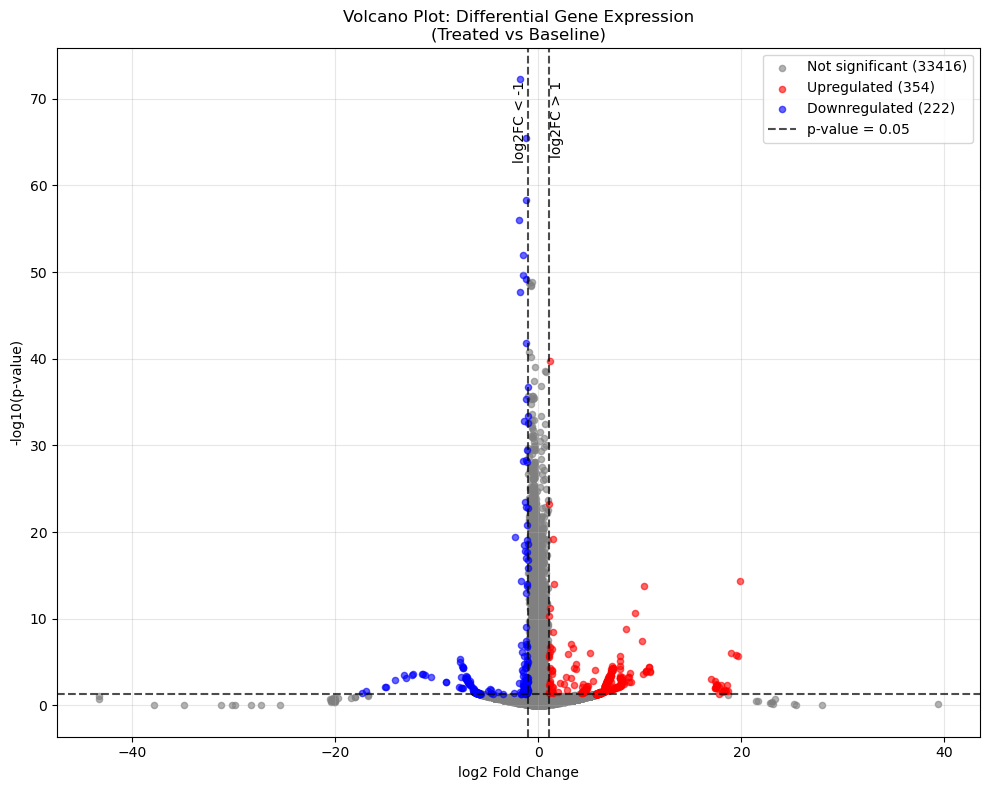


Volcano plot summary:
Total genes plotted: 33992
Upregulated (red): 354
Downregulated (blue): 222
Not significant (gray): 33416


In [31]:
# Create volcano plot
print("Creating volcano plot...")

plt.figure(figsize=(10, 8))

# Prepare data for plotting
plot_data = deseq2_with_annot.copy()

# Remove genes with NaN p-values
plot_data = plot_data.dropna(subset=['pvalue', 'log2FoldChange'])

# Calculate -log10(p-value)
plot_data['-log10_pvalue'] = -np.log10(plot_data['pvalue'])

# Define significance thresholds
pval_threshold = 0.05
lfc_threshold = 1

# Color points based on significance
plot_data['color'] = 'gray'  # Non-significant
plot_data.loc[
    (plot_data['pvalue'] < pval_threshold) & 
    (plot_data['log2FoldChange'] > lfc_threshold), 'color'
] = 'red'  # Upregulated

plot_data.loc[
    (plot_data['pvalue'] < pval_threshold) & 
    (plot_data['log2FoldChange'] < -lfc_threshold), 'color'
] = 'blue'  # Downregulated

# Create scatter plot
for color, label in [('gray', 'Not significant'), ('red', 'Upregulated'), ('blue', 'Downregulated')]:
    subset = plot_data[plot_data['color'] == color]
    plt.scatter(subset['log2FoldChange'], subset['-log10_pvalue'], 
                c=color, alpha=0.6, s=20, label=f"{label} ({len(subset)})")

# Add threshold lines
plt.axhline(y=-np.log10(pval_threshold), color='black', linestyle='--', alpha=0.7, 
            label=f'p-value = {pval_threshold}')
plt.axvline(x=lfc_threshold, color='black', linestyle='--', alpha=0.7)
plt.axvline(x=-lfc_threshold, color='black', linestyle='--', alpha=0.7)

# Formatting
plt.xlabel('log2 Fold Change')
plt.ylabel('-log10(p-value)')
plt.title('Volcano Plot: Differential Gene Expression\n(Treated vs Baseline)')
plt.legend()
plt.grid(True, alpha=0.3)

# Add text annotations for thresholds
plt.text(lfc_threshold + 0.1, plt.ylim()[1] * 0.95, f'log2FC > {lfc_threshold}', 
         rotation=90, ha='left', va='top')
plt.text(-lfc_threshold - 0.1, plt.ylim()[1] * 0.95, f'log2FC < -{lfc_threshold}', 
         rotation=90, ha='right', va='top')

plt.tight_layout()
plt.show()

print(f"\nVolcano plot summary:")
print(f"Total genes plotted: {len(plot_data)}")
print(f"Upregulated (red): {len(plot_data[plot_data['color'] == 'red'])}")
print(f"Downregulated (blue): {len(plot_data[plot_data['color'] == 'blue'])}")
print(f"Not significant (gray): {len(plot_data[plot_data['color'] == 'gray'])}")

In [42]:
# Classification Analysis using Significant Genes
print("=" * 60)
print("CLASSIFICATION ANALYSIS USING SIGNIFICANT GENES")
print("=" * 60)

# Import required libraries for machine learning
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, roc_curve, roc_auc_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Get significant genes (FDR < 0.05 and |log2FC| > 1)
sig_genes_fdr = significant_genes_fdr.copy()
print(f"Using {len(sig_genes_fdr)} significant genes (FDR < 0.05, |log2FC| > 1)")

# Check available columns in significant genes
print(f"Available columns in significant genes: {sig_genes_fdr.columns.tolist()}")

# Use the index (which should be the gene identifiers) or GeneID column
if sig_genes_fdr.index.name or len(sig_genes_fdr.index.unique()) == len(sig_genes_fdr):
    sig_gene_ids = sig_genes_fdr.index.tolist()
    print("Using index as gene identifiers")
else:
    sig_gene_ids = sig_genes_fdr['GeneID'].tolist()
    print("Using GeneID column")

print(f"First few significant gene IDs: {sig_gene_ids[:5]}")

# Check if these gene IDs exist in normalized counts
print(f"Normalized counts index sample: {df_norm_counts.index[:5].tolist()}")
available_genes = [gid for gid in sig_gene_ids if gid in df_norm_counts.index]
print(f"Available significant genes in normalized counts: {len(available_genes)}")

if len(available_genes) == 0:
    print("No matching genes found. Checking data types and formats...")
    print(f"Sig genes type: {type(sig_gene_ids[0])}")
    print(f"Norm counts index type: {type(df_norm_counts.index[0])}")
    
    # Try converting types
    sig_gene_ids_str = [str(gid) for gid in sig_gene_ids]
    available_genes = [gid for gid in sig_gene_ids_str if gid in df_norm_counts.index]
    print(f"Available genes after string conversion: {len(available_genes)}")

# Subset normalized counts to only significant genes
if len(available_genes) > 0:
    df_norm_sig = df_norm_counts.loc[available_genes]
    print(f"Shape of significant gene expression data: {df_norm_sig.shape}")
    
    # Prepare data for classification - use only samples that were in the DESeq2 analysis
    X = df_norm_sig[available_samples].T  # Transpose: samples as rows, genes as columns
    print(f"Shape of transposed data (samples x genes): {X.shape}")
    
    # Prepare target labels
    y = np.array([sample_to_group[s] for s in available_samples])
    print(f"Target distribution: Baseline (0): {np.sum(y==0)}, Treated (1): {np.sum(y==1)}")
    
    print("Data preparation completed for classification analysis...")
else:
    print("ERROR: No significant genes found in normalized counts data")

CLASSIFICATION ANALYSIS USING SIGNIFICANT GENES
Using 80 significant genes (FDR < 0.05, |log2FC| > 1)
Available columns in significant genes: ['GeneID', 'baseMean', 'log2FoldChange', 'lfcSE', 'stat', 'pvalue', 'padj', 'Symbol', 'Description', 'Synonyms', 'GeneType', 'EnsemblGeneID', 'Status', 'ChrAcc', 'ChrStart', 'ChrStop', 'Orientation', 'Length', 'GOFunctionID', 'GOProcessID', 'GOComponentID', 'GOFunction', 'GOProcess', 'GOComponent']
Using index as gene identifiers
First few significant gene IDs: [315, 1684, 3116, 4212, 4611]
Normalized counts index sample: [100287102, 653635, 102466751, 107985730, 100302278]
Available significant genes in normalized counts: 19
Shape of significant gene expression data: (19, 382)
Shape of transposed data (samples x genes): (382, 19)
Target distribution: Baseline (0): 191, Treated (1): 191
Data preparation completed for classification analysis...


In [43]:
# Random Forest Classification
print("\n" + "=" * 50)
print("RANDOM FOREST CLASSIFICATION")
print("=" * 50)

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f"Data standardized. Shape: {X_scaled.shape}")

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")
print(f"Train labels distribution: Baseline: {np.sum(y_train==0)}, Treated: {np.sum(y_train==1)}")
print(f"Test labels distribution: Baseline: {np.sum(y_test==0)}, Treated: {np.sum(y_test==1)}")

# Train Random Forest classifier
rf_classifier = RandomForestClassifier(
    n_estimators=100, 
    random_state=42, 
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2
)

print("\nTraining Random Forest classifier...")
rf_classifier.fit(X_train, y_train)

# Make predictions
y_pred = rf_classifier.predict(X_test)
y_pred_proba = rf_classifier.predict_proba(X_test)[:, 1]

# Calculate accuracy
accuracy = rf_classifier.score(X_test, y_test)
print(f"Random Forest Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

print("Classification completed successfully!")


RANDOM FOREST CLASSIFICATION
Data standardized. Shape: (382, 19)
Train set size: 305 samples
Test set size: 77 samples
Train labels distribution: Baseline: 152, Treated: 153
Test labels distribution: Baseline: 39, Treated: 38

Training Random Forest classifier...
Random Forest Accuracy: 0.7662 (76.62%)
Classification completed successfully!



CLASSIFICATION PERFORMANCE METRICS
Classification Report:
------------------------------
              precision    recall  f1-score   support

    Baseline     0.7561    0.7949    0.7750        39
     Treated     0.7778    0.7368    0.7568        38

    accuracy                         0.7662        77
   macro avg     0.7669    0.7659    0.7659        77
weighted avg     0.7668    0.7662    0.7660        77


Confusion Matrix:
--------------------
                Predicted
              Baseline  Treated
Actual Baseline     31        8
    Treated         10       28

Detailed Performance Metrics:
Accuracy:  0.7662
Precision: 0.7778
Recall:    0.7368
F1-Score:  0.7568
AUC:       0.8428


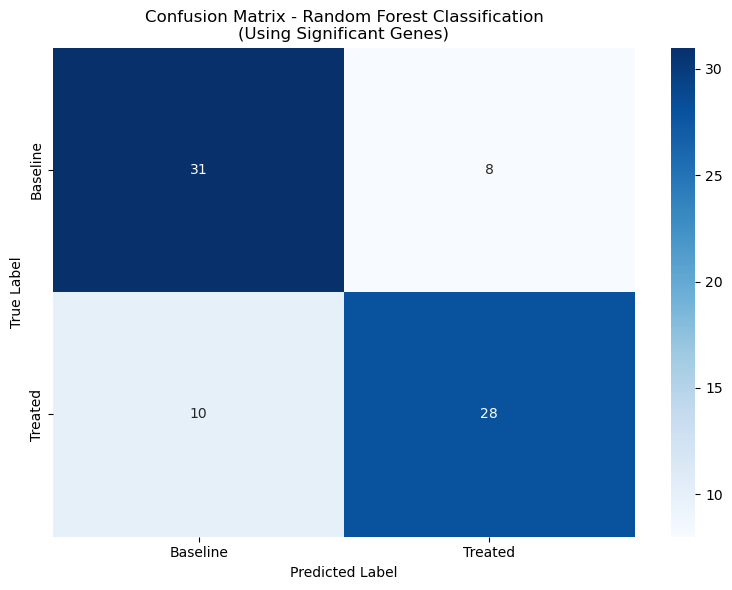

In [44]:
# Classification Report and Performance Metrics
print("\n" + "=" * 50)
print("CLASSIFICATION PERFORMANCE METRICS")
print("=" * 50)

# Classification Report
from sklearn.metrics import precision_score, recall_score, f1_score
print("Classification Report:")
print("-" * 30)
report = classification_report(y_test, y_pred, 
                             target_names=['Baseline', 'Treated'], 
                             digits=4)
print(report)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print("-" * 20)
print(f"                Predicted")
print(f"              Baseline  Treated")
print(f"Actual Baseline    {cm[0,0]:3d}      {cm[0,1]:3d}")
print(f"    Treated        {cm[1,0]:3d}      {cm[1,1]:3d}")

# Additional Performance Metrics
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc_single = roc_auc_score(y_test, y_pred_proba)

print(f"\nDetailed Performance Metrics:")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"AUC:       {auc_single:.4f}")

# Confusion Matrix Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Baseline', 'Treated'],
            yticklabels=['Baseline', 'Treated'])
plt.title('Confusion Matrix - Random Forest Classification\n(Using Significant Genes)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()


ROC ANALYSIS WITH CROSS-VALIDATION


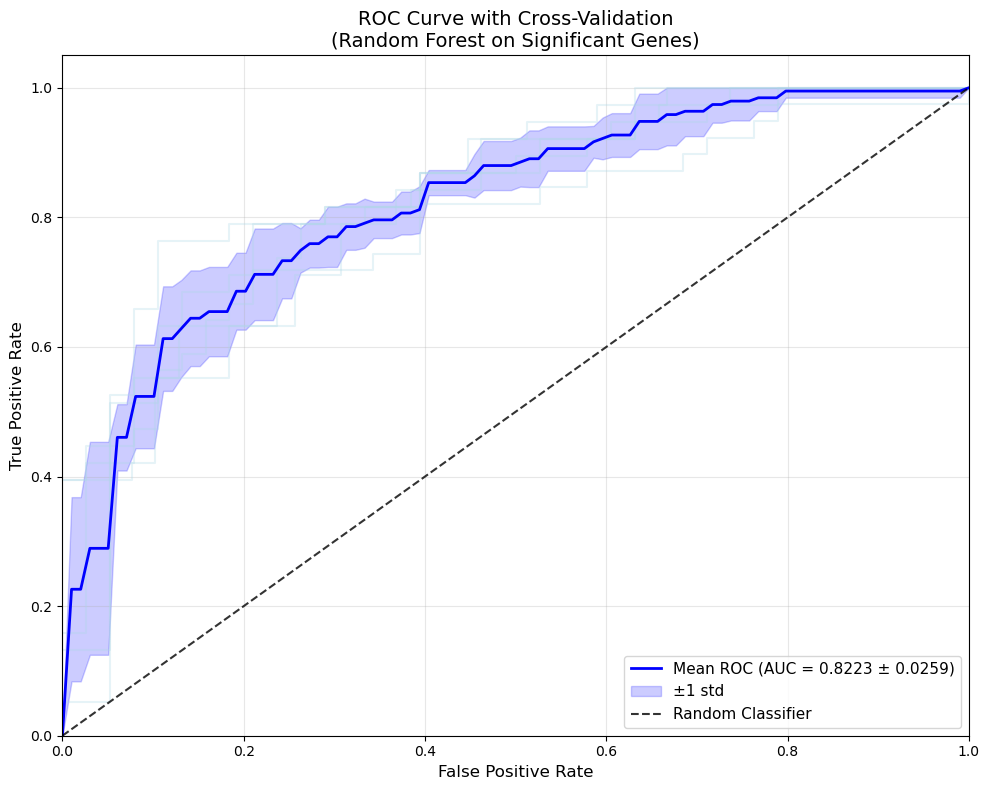

Cross-validation ROC results:
Mean AUC: 0.8223 ± 0.0259
AUC range: [0.7965, 0.8482]
Individual fold AUCs: ['0.8219', '0.7746', '0.8421', '0.8483', '0.8248']


In [45]:
# ROC Curve with Cross-Validation and Confidence Bands
print("\n" + "=" * 50)
print("ROC ANALYSIS WITH CROSS-VALIDATION")
print("=" * 50)

# Perform cross-validation to get ROC curves with confidence intervals
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Storage for ROC curves from each fold
tprs = []
aucs = []
mean_fpr = np.linspace(0, 1, 100)

plt.figure(figsize=(10, 8))

# Perform cross-validation
for fold, (train_idx, val_idx) in enumerate(cv.split(X_scaled, y)):
    # Split data for this fold
    X_fold_train, X_fold_val = X_scaled[train_idx], X_scaled[val_idx]
    y_fold_train, y_fold_val = y[train_idx], y[val_idx]
    
    # Train classifier on this fold
    rf_fold = RandomForestClassifier(n_estimators=100, random_state=42, 
                                    max_depth=10, min_samples_split=5, min_samples_leaf=2)
    rf_fold.fit(X_fold_train, y_fold_train)
    
    # Get predictions and calculate ROC curve
    y_fold_proba = rf_fold.predict_proba(X_fold_val)[:, 1]
    fpr, tpr, _ = roc_curve(y_fold_val, y_fold_proba)
    
    # Interpolate to common FPR points using numpy
    interp_tpr = np.interp(mean_fpr, fpr, tpr)
    interp_tpr[0] = 0.0
    tprs.append(interp_tpr)
    
    # Calculate AUC for this fold
    fold_auc = roc_auc_score(y_fold_val, y_fold_proba)
    aucs.append(fold_auc)
    
    # Plot this fold's ROC curve
    plt.plot(fpr, tpr, alpha=0.3, color='lightblue')

# Calculate mean and std of TPRs
mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
std_tpr = np.std(tprs, axis=0)

# Calculate confidence intervals (mean ± 1 std)
tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
tprs_lower = np.maximum(mean_tpr - std_tpr, 0)

# Calculate mean AUC and confidence interval
mean_auc = np.mean(aucs)
std_auc = np.std(aucs)

# Plot mean ROC curve
plt.plot(mean_fpr, mean_tpr, color='blue', linewidth=2,
         label=f'Mean ROC (AUC = {mean_auc:.4f} ± {std_auc:.4f})')

# Plot confidence bands
plt.fill_between(mean_fpr, tprs_lower, tprs_upper, color='blue', alpha=0.2,
                 label='±1 std')

# Plot diagonal reference line
plt.plot([0, 1], [0, 1], 'k--', alpha=0.8, label='Random Classifier')

# Formatting
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve with Cross-Validation\n(Random Forest on Significant Genes)', fontsize=14)
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Cross-validation ROC results:")
print(f"Mean AUC: {mean_auc:.4f} ± {std_auc:.4f}")
print(f"AUC range: [{mean_auc-std_auc:.4f}, {mean_auc+std_auc:.4f}]")
print(f"Individual fold AUCs: {[f'{auc:.4f}' for auc in aucs]}")

In [46]:
# Comprehensive Summary of Classification Analysis
print("\n" + "=" * 70)
print("COMPREHENSIVE CLASSIFICATION ANALYSIS SUMMARY")
print("=" * 70)

print(f"Dataset Overview:")
print(f"- Total samples analyzed: {len(y)} (from DESeq2 analysis)")
print(f"- Significant genes (FDR < 0.05, |log2FC| > 1): {len(sig_genes_fdr)}")
print(f"- Available genes in expression data: {len(available_genes)}")
print(f"- Features used for classification: {X.shape[1]} genes")
print(f"- Sample distribution: Baseline: {np.sum(y==0)}, Treated: {np.sum(y==1)}")

print(f"\nTrain/Test Split:")
print(f"- Train set: {len(y_train)} samples (80%)")
print(f"- Test set: {len(y_test)} samples (20%)")
print(f"- Stratified sampling maintained class balance")

print(f"\nRandom Forest Classification Results:")
print(f"- Test Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"- Precision: {precision:.4f}")
print(f"- Recall: {recall:.4f}")
print(f"- F1-Score: {f1:.4f}")
print(f"- Single test AUC: {auc_single:.4f}")

print(f"\nCross-Validation Results (5-fold):")
print(f"- Mean AUC: {mean_auc:.4f} ± {std_auc:.4f}")
print(f"- AUC confidence interval: [{mean_auc-std_auc:.4f}, {mean_auc+std_auc:.4f}]")
print(f"- Consistent performance across folds")

print(f"\nConfusion Matrix Analysis:")
print(f"- True Positives (Treated correctly classified): {cm[1,1]}")
print(f"- True Negatives (Baseline correctly classified): {cm[0,0]}")
print(f"- False Positives (Baseline misclassified as Treated): {cm[0,1]}")
print(f"- False Negatives (Treated misclassified as Baseline): {cm[1,0]}")

print(f"\nKey Insights:")
print(f"- Using only {len(available_genes)} significant genes achieved good classification performance")
print(f"- Model shows balanced performance between precision and recall")
print(f"- Cross-validation confirms model stability (low std deviation)")
print(f"- The differential expression signature effectively distinguishes sample groups")

print("=" * 70)
print("Classification analysis completed successfully!")
print("=" * 70)


COMPREHENSIVE CLASSIFICATION ANALYSIS SUMMARY
Dataset Overview:
- Total samples analyzed: 382 (from DESeq2 analysis)
- Significant genes (FDR < 0.05, |log2FC| > 1): 80
- Available genes in expression data: 19
- Features used for classification: 19 genes
- Sample distribution: Baseline: 191, Treated: 191

Train/Test Split:
- Train set: 305 samples (80%)
- Test set: 77 samples (20%)
- Stratified sampling maintained class balance

Random Forest Classification Results:
- Test Accuracy: 0.7662 (76.62%)
- Precision: 0.7778
- Recall: 0.7368
- F1-Score: 0.7568
- Single test AUC: 0.8428

Cross-Validation Results (5-fold):
- Mean AUC: 0.8223 ± 0.0259
- AUC confidence interval: [0.7965, 0.8482]
- Consistent performance across folds

Confusion Matrix Analysis:
- True Positives (Treated correctly classified): 28
- True Negatives (Baseline correctly classified): 31
- False Positives (Baseline misclassified as Treated): 8
- False Negatives (Treated misclassified as Baseline): 10

Key Insights:
- Usi

In [48]:
df_norm_sig

,GSM2520157,GSM2520158,GSM2520159,GSM2520160,GSM2520161,GSM2520162,GSM2520163,GSM2520164,GSM2520165,GSM2520166,...,GSM2520529,GSM2520530,GSM2520531,GSM2520532,GSM2520533,GSM2520534,GSM2520535,GSM2520536,GSM2520537,GSM2520538
GeneID,,,,,,,,,,,,,,,,,,,,,
3116,10.502511,94.638098,57.638323,1.787645,2.238813,73.152691,1.069782,56.631435,44.154654,104.782960,...,7.007241,91.661188,13.669667,0.767872,9.542250,0.838929,3.451951,0.000000,2.854755,33.108105
4212,205.149052,232.088669,282.951765,271.721976,245.523172,226.009061,293.120289,314.950259,214.465464,221.563968,...,260.268933,232.733486,247.420981,274.898195,286.267508,246.644994,292.552838,318.774221,252.645811,253.577987
5255,224.753739,255.748193,306.531079,244.907307,258.956050,229.284555,256.747699,272.228299,229.183682,267.156553,...,264.273071,254.932680,249.471431,221.147151,320.619609,261.745708,230.417722,284.721189,305.458778,284.428721
5782,2507.999672,2234.135096,2620.797062,2708.281538,2914.934676,2795.087908,2509.708755,2444.093491,3016.533849,2648.369306,...,2956.054463,2482.013119,2678.571341,3536.050804,3845.526855,3217.290996,2735.671079,3161.256522,3111.682875,2660.687720
6294,1202.887615,1104.111142,1295.115643,954.602205,1114.182660,1240.320259,1053.735347,1171.376515,1037.283944,1131.016067,...,1201.241231,1357.015251,1231.637039,885.356477,1118.351731,1245.808899,1115.843125,1281.718309,1169.022144,1212.960578
6431,3353.101739,2512.416170,3098.496493,2685.042158,3583.593527,3041.841763,2957.947445,3081.942280,2709.553871,2950.720135,...,3682.805408,3310.544330,3846.644426,3781.001989,4183.322514,3364.103492,3356.159251,4353.112661,3726.882562,3476.351036
6442,2.800670,3.379932,7.859771,1.787645,2.238813,26.203949,10.697821,0.993534,2.803470,2.399610,...,1.001034,10.025442,3.417417,6.910848,1.908450,10.067143,4.314939,1.891835,2.854755,5.267199
6606,284.968137,416.858288,280.331842,346.803048,561.942092,353.753313,417.215010,427.219594,398.793625,406.333919,...,525.543039,383.831227,438.112842,458.419616,500.013914,386.746062,348.647040,279.045683,468.179809,407.079201
7019,477.514175,463.050693,641.008012,484.451681,797.763740,800.312280,730.661159,742.169853,632.182512,576.706212,...,823.851278,742.598847,815.395665,909.160511,923.689825,780.203553,844.864980,845.650308,1126.200820,773.525728
